<a href="https://colab.research.google.com/github/springboard5678x/Dynamic-Text-Analysis-System/blob/vaishnavi-branch/Dynamic_Text_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  # installing kaggle library
! pip install kaggle

Upload your kaggle.json file in drive/MyDrive

In [ ]:
# configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Importing Twitter Sentiment dataset

In [ ]:
# API to fetch the dataset from kaggle
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
 58% 47.0M/80.9M [00:00<00:00, 483MB/s]
100% 80.9M/80.9M [00:00<00:00, 550MB/s]


In [ ]:
# extracting the compressed dataset
from zipfile import ZipFile
dataset='/content/sentiment140.zip'

with ZipFile(dataset, 'r') as zip:

  zip.extractall()

  print('The dataset is extracted')

The dataset is extracted


Importing the Dependencies

In [ ]:
import numpy as np

import pandas as pd

import re

from nltk.corpus import stopwords

from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# printing the stopwords in English
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
# loading the data from csv file to pandas dataframe
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1')

Data processing

In [ ]:
twitter_data.shape

(1599999, 6)

"Why 1,599,999? Because indexing starts from 0, so we adjust it in the next steps."

In [ ]:
# printing the first 5 rows of the dataframe
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
# Naming the columns and reading the dataset again, because we can observe in the above step that the columns are not named
column_names = ['target' , 'id' ,'date', 'flag','user','text']
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', names = column_names, encoding='ISO-8859-1')

In [ ]:
 # checking the number of rows and columns
 twitter_data.shape

(1600000, 6)

In [ ]:
twitter_data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


target = 0 → negative sentiment
id = 1467810369 → tweet ID
date = Mon Apr 06 22:19:45 PDT 2009 → when it was posted
flag = NO_QUERY → not part of a query
user = TheSpecialOne → Twitter handle
text = tweet content

Why flag?
It indicates which query or keyword was used to collect that tweet.
For example:
flag value	meaning
NO_QUERY	The tweet wasn’t collected using any specific search keyword.
happy -	The tweet was collected using the keyword “happy”.
sad -	The tweet was collected using the keyword “sad”.


In [ ]:
# counting the number of missing values in the dataset
twitter_data.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


1) Find number of twitters

In [ ]:
# checking the distribution of target column
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


Convert the target 4 to 1

In [ ]:
twitter_data.replace({'target':{4:1}}, inplace=True) # why inplace = true beacause to replace or use it in original or recent.

In [ ]:
print(twitter_data['target'].value_counts())

target
0    800000
1    800000
Name: count, dtype: int64


Keep 3 labels: 0 (Negative), 2 (Neutral), 4 (Positive)



Stemming is the process of reducing a word to its Root word

example: actor,actress,acting = act

In [ ]:
port_stem = PorterStemmer()

Important part of this code

In [ ]:
def stemming(content):

 stemmed_content = re.sub('[^a-zA-Z]',' ', content) # removing that are not letters like @,1,etc.
 stemmed_content = stemmed_content.lower() # because capital don't add any meaning to context.
 stemmed_content = stemmed_content.split() # after split adding into list
 stemmed_content=[port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')] # Checking if there are any stopwords and if present, then it will be ignore in this step.
 stemmed_content = ' '.join(stemmed_content)

 return stemmed_content

In [ ]:
twitter_data['stemmed_content'] = twitter_data['text'].apply(stemming) # 50 minutes to run

In [ ]:
twitter_data.head()

,target,id,date,flag,user,text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",switchfoot http twitpic com zl awww bummer sho...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,kenichan dive mani time ball manag save rest g...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",nationwideclass behav mad see


In [ ]:
print(twitter_data['stemmed_content']) # It prints id & text(tweet)

0          switchfoot http twitpic com zl awww bummer sho...
1          upset updat facebook text might cri result sch...
2          kenichan dive mani time ball manag save rest g...
3                            whole bodi feel itchi like fire
4                              nationwideclass behav mad see
                                 ...                        
1599995                           woke school best feel ever
1599996    thewdb com cool hear old walt interview http b...
1599997                         readi mojo makeov ask detail
1599998    happi th birthday boo alll time tupac amaru sh...
1599999    happi charitytuesday thenspcc sparkschar speak...
Name: stemmed_content, Length: 1600000, dtype: object


In [ ]:
print(twitter_data['target']) # id & Target

0          0
1          0
2          0
3          0
4          0
          ..
1599995    1
1599996    1
1599997    1
1599998    1
1599999    1
Name: target, Length: 1600000, dtype: int64


In [ ]:
X = twitter_data['stemmed_content'].values
Y = twitter_data['target'].values

In [ ]:
print(X)

['switchfoot http twitpic com zl awww bummer shoulda got david carr third day'
 'upset updat facebook text might cri result school today also blah'
 'kenichan dive mani time ball manag save rest go bound' ...
 'readi mojo makeov ask detail'
 'happi th birthday boo alll time tupac amaru shakur'
 'happi charitytuesday thenspcc sparkschar speakinguph h']


In [ ]:
print(Y)

[0 0 0 ... 1 1 1]


Splitting the data to training data and test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 2)
# test_size = 0.2 indicates that 20% of the dataset will be used for testing, while the remaining 80% will be used for training the model.
# stratify = Y because Ensures that the proportion of each class in Y is preserved in both train and test sets.
# Without stratify, the split might randomly assign more samples of one class to either train or test, causing imbalance.

In [ ]:
print(X.shape, Y_train.shape, X_test.shape)

(1600000,) (1280000,) (320000,)


In [ ]:
print(X_test)

['mmangen fine much time chat twitter hubbi back summer amp tend domin free time'
 'ah may show w ruth kim amp geoffrey sanhueza'
 'ishatara mayb bay area thang dammit' ...
 'destini nevertheless hooray member wonder safe trip' 'feel well'
 'supersandro thank']


Feature extration

In [ ]:
#converting the textual data to numerical data

vectorizer = TfidfVectorizer() # Vectorizer(function) transforms text into numerical features by counting word occurrences. Frequent and meaningful words, like 'happy', help the model distinguish between positive and negative tweets.

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

In [ ]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9453092 stored elements and shape (1280000, 461488)>
  Coords	Values
  (0, 436713)	0.27259876264838384
  (0, 354543)	0.3588091611460021
  (0, 185193)	0.5277679060576009
  (0, 109306)	0.3753708587402299
  (0, 235045)	0.41996827700291095
  (0, 443066)	0.4484755317023172
  (1, 160636)	1.0
  (2, 109306)	0.4591176413728317
  (2, 124484)	0.1892155960801415
  (2, 407301)	0.18709338684973031
  (2, 129411)	0.29074192727957143
  (2, 406399)	0.32105459490875526
  (2, 433560)	0.3296595898028565
  (2, 77929)	0.31284080750346344
  (2, 443430)	0.3348599670252845
  (2, 266729)	0.24123230668976975
  (2, 409143)	0.15169282335109835
  (2, 178061)	0.1619010109445149
  (2, 150715)	0.18803850583207948
  (2, 132311)	0.2028971570399794
  (2, 288470)	0.16786949597862733
  (3, 406399)	0.29029991238662284
  (3, 158711)	0.4456939372299574
  (3, 151770)	0.278559647704793
  (3, 56476)	0.5200465453608686
  :	:
  (1279996, 318303)	0.21254698865277744
  (12

In [ ]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2289192 stored elements and shape (320000, 461488)>
  Coords	Values
  (0, 15110)	0.1719352837797837
  (0, 31168)	0.1624772418052177
  (0, 67828)	0.26800375270827315
  (0, 106069)	0.36555450010904555
  (0, 132364)	0.255254889555786
  (0, 138164)	0.23688292264071406
  (0, 171378)	0.2805816206356074
  (0, 271016)	0.45356623916588285
  (0, 279082)	0.17825180109103442
  (0, 388348)	0.2198507607206174
  (0, 398906)	0.34910438732642673
  (0, 409143)	0.3143047059807971
  (0, 420984)	0.17915624523539805
  (1, 6463)	0.30733520460524466
  (1, 15110)	0.211037449588008
  (1, 145393)	0.575262969264869
  (1, 217562)	0.40288153995289894
  (1, 256777)	0.28751585696559306
  (1, 348135)	0.4739279595416274
  (1, 366203)	0.24595562404108307
  (2, 22532)	0.3532582957477176
  (2, 34401)	0.37916255084357414
  (2, 89448)	0.36340369428387626
  (2, 183312)	0.5892069252021465
  (2, 256834)	0.2564939661498776
  :	:
  (319994, 443794)	0.2782185641032538


Training the Machine Learning Model

Logistic Regression

In [ ]:
model = LogisticRegression(max_iter=1000) # maximum no.of model can go through the data

In [ ]:
model.fit(X_train, Y_train) # model.fit(X_train, Y_train) trains the model by learning patterns between input features and their corresponding output labels.

LogisticRegression(max_iter=1000)

Model Evaluation

Accuracy score

In [ ]:
# accuracy score on the training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [ ]:
print('Accuracy score on the training data:', training_data_accuracy)

Accuracy score on the training data: 0.79871953125


In [ ]:
# accuracy score on the test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

In [ ]:
print('Accuracy score on the test data:', test_data_accuracy)

Accuracy score on the test data: 0.77668125


Model accuary = 77.8 %

Saving the trained model

In [ ]:
import pickle

In [ ]:
filename = 'trained_model.sav'
pickle.dump(model, open(filename,'wb'))

In [ ]:
# loading the saved model
loaded_model = pickle.load(open('/content/trained_model.sav','rb'))

In [ ]:
pickle.dump(vectorizer, open('vectorizer.sav', 'wb'))

In [ ]:
vectorizer = pickle.load(open('vectorizer.sav', 'rb'))

In [ ]:
# Try any random test sample
sample_index = 205
print("Actual Sentiment:", Y_test[sample_index])

prediction = loaded_model.predict(X_test[sample_index])
print("Predicted Sentiment:", prediction)

if prediction[0] == 0:
    print("Negative Tweet")
elif prediction[0] == 2:
    print("Neutral Tweet")
else:
    print("Positive Tweet")


Actual Sentiment: 0
Predicted Sentiment: [1]
Positive Tweet


In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import pickle

# Load only the model (you already have vectorizer in memory)
loaded_model = pickle.load(open('trained_model.sav', 'rb'))

# Define stemming function (same as training)
port_stem = PorterStemmer()
def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    return ' '.join(stemmed_content)

# ----- ✨ INPUT YOUR TEXT HERE -----
user_input = input("Enter a tweet or sentence: ")

# Preprocess
processed_input = stemming(user_input)

# Convert text to numeric (using the vectorizer you trained earlier)
vector_input = vectorizer.transform([processed_input])

# Predict sentiment
prediction = loaded_model.predict(vector_input)

# Print result
if prediction[0] == 0:
    print("🟥 Sentiment: Negative")
elif prediction[0] == 2:
    print("🟨 Sentiment: Neutral")
else:
    print("🟩 Sentiment: Positive")


Enter a tweet or sentence: Thr product is bad
🟥 Sentiment: Negative


/tmp/ipython-input-2979941034.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




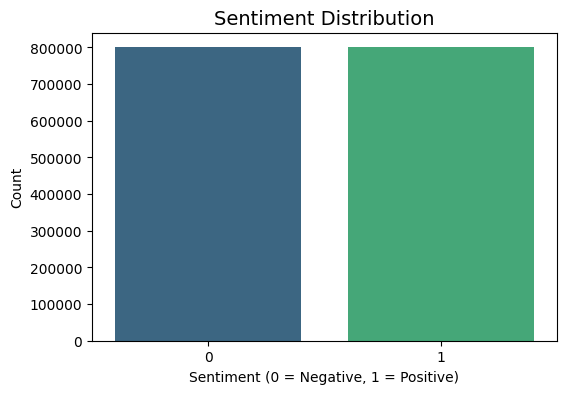

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Naming the columns and reading the dataset
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    names=column_names,
    encoding='ISO-8859-1'
)

# Convert 4 → 1 (Positive sentiment)
twitter_data['target'] = twitter_data['target'].replace({4: 1})

# Plotting the sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=twitter_data, x='target', palette='viridis')
plt.title('Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Count')
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Read the dataset
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    names=column_names,
    encoding='ISO-8859-1'
)

# Map sentiment values to labels for better readability
twitter_data['Sentiment'] = twitter_data['target'].map({0: 'Negative', 4: 'Positive'})

# Count each sentiment
sentiment_counts = twitter_data['Sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Create the pie chart
fig = px.pie(
    sentiment_counts,
    names='Sentiment',
    values='Count',
    title='Sentiment Distribution of Tweets',
    color='Sentiment',
    color_discrete_map={'Positive': 'green', 'Negative': 'red'}
)
# Create the pie chart
fig = px.pie(
    sentiment_counts,
    names='Sentiment',
    values='Count',
    title='Sentiment Distribution of Tweets',
    color='Sentiment',
    color_discrete_map={'Positive': 'green', 'Negative': 'red'}
)

# Reduce chart size
fig.update_layout(
    width=500,   # change width
    height=400,  # change height
    title_font_size=18
)

# Display the chart
fig.show()


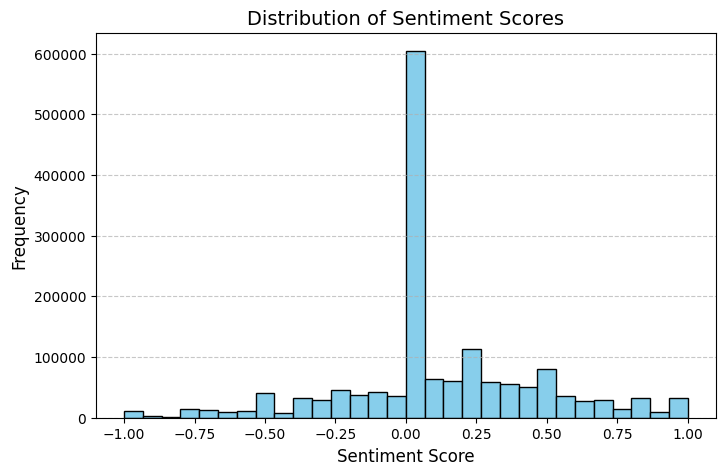

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

# Read the dataset
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    names=column_names,
    encoding='ISO-8859-1'
)

# Compute sentiment polarity scores using TextBlob
# (Score ranges from -1 = very negative to +1 = very positive)
twitter_data['sentiment_score'] = twitter_data['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Plot histogram of sentiment scores
plt.figure(figsize=(8, 5))
plt.hist(twitter_data['sentiment_score'], bins=30, color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Distribution of Sentiment Scores', fontsize=14)
plt.xlabel('Sentiment Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

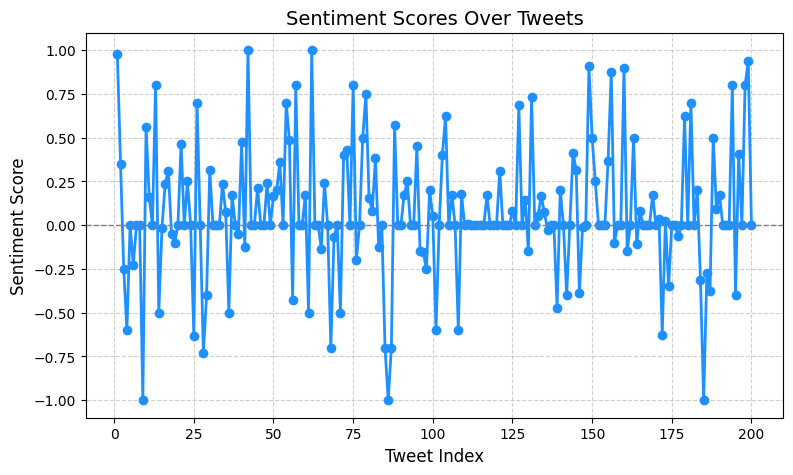

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

# Read your dataset
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    names=column_names,
    encoding='ISO-8859-1'
)

# --- Optional: Use a smaller sample for faster computation ---
twitter_sample = twitter_data.sample(200, random_state=42).reset_index(drop=True)

# Compute sentiment polarity for each tweet using TextBlob
twitter_sample['sentiment_score'] = twitter_sample['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Create a line plot of sentiment scores across documents
plt.figure(figsize=(9, 5))
plt.plot(
    twitter_sample.index + 1,
    twitter_sample['sentiment_score'],
    marker='o',
    color='dodgerblue',
    linewidth=2
)

# Add a horizontal neutral line
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Add titles and labels
plt.title("Sentiment Scores Over Tweets", fontsize=14)
plt.xlabel("Tweet Index", fontsize=12)
plt.ylabel("Sentiment Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

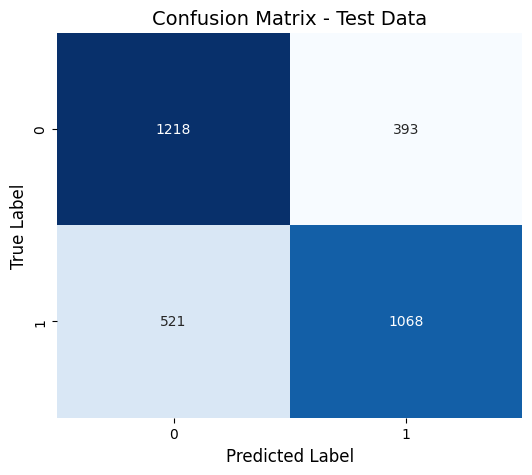


Classification Report:

              precision    recall  f1-score   support

    Negative       0.70      0.76      0.73      1611
    Positive       0.73      0.67      0.70      1589

    accuracy                           0.71      3200
   macro avg       0.72      0.71      0.71      3200
weighted avg       0.72      0.71      0.71      3200



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report

# -------------------------
# Step 1️⃣ - Load the dataset
# -------------------------
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    names=column_names,
    encoding='ISO-8859-1'
)

# Convert target values (0 = Negative, 4 = Positive)
twitter_data['target'] = twitter_data['target'].map({0: 0, 4: 1})

# -------------------------
# Step 2️⃣ - Prepare data
# -------------------------
X = twitter_data['text']
y = twitter_data['target']

# For faster testing, use a smaller sample
X_sample, _, y_sample, _ = train_test_split(X, y, test_size=0.99, random_state=42)

# -------------------------
# Step 3️⃣ - Train/Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# -------------------------
# Step 4️⃣ - Model Training
# -------------------------
vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

# -------------------------
# Step 5️⃣ - Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Data', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# -------------------------
# Step 6️⃣ - Optional: Classification Report
# -------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.1 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


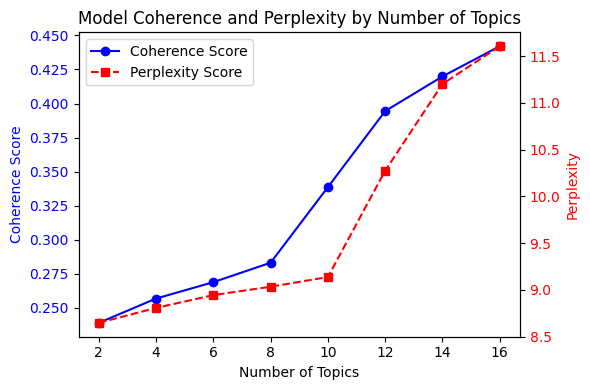

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from gensim import corpora, models
from gensim.models import CoherenceModel

# -------------------------
# Step 1️⃣ - Load your dataset
# -------------------------
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    names=column_names,
    encoding='ISO-8859-1'
)

# Optional: take a small sample for faster training
sample_data = twitter_data['text'].sample(5000, random_state=42)

# -------------------------
# Step 2️⃣ - Text Preprocessing
# -------------------------
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'[^A-Za-z\s]', '', text.lower())      # keep only letters
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

processed_docs = sample_data.apply(preprocess)

# -------------------------
# Step 3️⃣ - Dictionary & Corpus
# -------------------------
dictionary = corpora.Dictionary(processed_docs)
corpus = [dictionary.doc2bow(text) for text in processed_docs]

# -------------------------
# Step 4️⃣ - Train LDA models for multiple topic numbers
# -------------------------
coherence_values = []
perplexity_values = []
num_topics_list = [2, 4, 6, 8, 10, 12, 14, 16]

for num in num_topics_list:
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num,
        random_state=42,
        passes=5,
        alpha='auto',
        per_word_topics=True
    )

    # Compute coherence
    coherence_model = CoherenceModel(model=lda_model, texts=processed_docs,
                                     dictionary=dictionary, coherence='c_v')
    coherence = coherence_model.get_coherence()
    coherence_values.append(coherence)

    # Compute perplexity
    perplexity = lda_model.log_perplexity(corpus)
    perplexity_values.append(abs(perplexity))  # abs() to make it positive for plotting

# -------------------------
# Step 5️⃣ - Plot both metrics
# -------------------------
# Step 5️⃣ - Plot both metrics
fig, ax1 = plt.subplots(figsize=(6,4))   # reduced size

# Coherence curve
ax1.plot(num_topics_list, coherence_values, 'o-', color='blue', label='Coherence Score')
ax1.set_xlabel('Number of Topics', fontsize=10)
ax1.set_ylabel('Coherence Score', color='blue', fontsize=10)
ax1.tick_params(axis='y', labelcolor='blue')

# Perplexity curve (right axis)
ax2 = ax1.twinx()
ax2.plot(num_topics_list, perplexity_values, 's--', color='red', label='Perplexity Score')
ax2.set_ylabel('Perplexity', color='red', fontsize=10)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Model Coherence and Perplexity by Number of Topics', fontsize=12)
fig.tight_layout()

# Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='best')

plt.show()


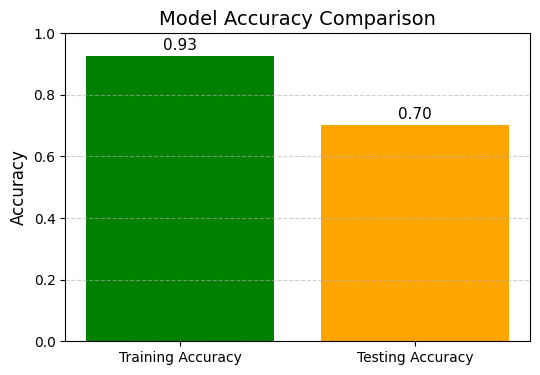

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# -------------------------
# Step 1️⃣ - Load dataset
# -------------------------
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    names=column_names,
    encoding='ISO-8859-1'
)

# Convert target values (0 = Negative, 4 = Positive)
twitter_data['target'] = twitter_data['target'].map({0: 0, 4: 1})

# Optional: sample smaller data for speed
twitter_sample = twitter_data.sample(10000, random_state=42)

# -------------------------
# Step 2️⃣ - Split data
# -------------------------
X = twitter_sample['text']
y = twitter_sample['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------
# Step 3️⃣ - Vectorize and Train model
# -------------------------
vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

# -------------------------
# Step 4️⃣ - Accuracy Scores
# -------------------------
training_data_accuracy = model.score(X_train_vec, y_train)
test_data_accuracy = model.score(X_test_vec, y_test)

# -------------------------
# Step 5️⃣ - Visualization
# -------------------------
plt.figure(figsize=(6,4))
plt.bar(['Training Accuracy', 'Testing Accuracy'],
        [training_data_accuracy, test_data_accuracy],
        color=['green', 'orange'])

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on top of bars
for i, v in enumerate([training_data_accuracy, test_data_accuracy]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

plt.show()

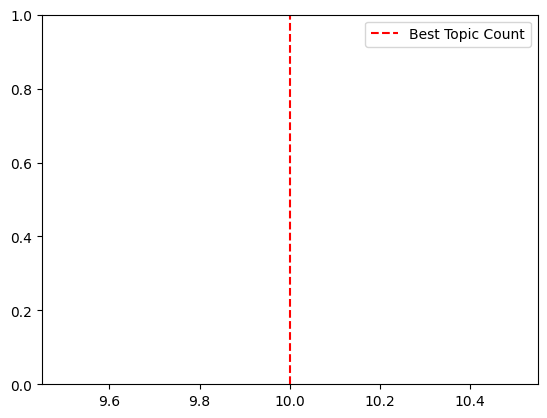

In [ ]:
plt.axvline(x=10, color='red', linestyle='--', label='Best Topic Count')
plt.legend()

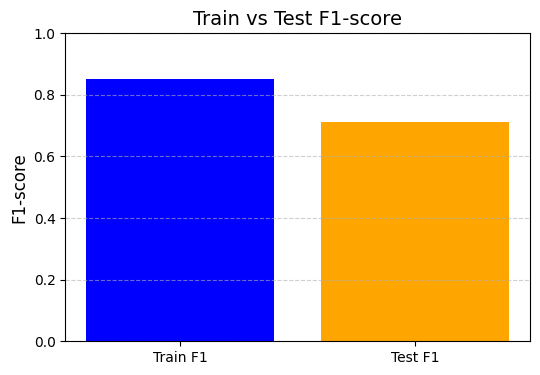

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# --- Calculate F1-scores (use your actual variables) ---
train_f1 = f1_score(Y_train, Y_train_pred, average='weighted')
test_f1 = f1_score(Y_test, Y_test_pred, average='weighted')

# --- Plot comparison ---
plt.figure(figsize=(6,4))
plt.bar(['Train F1', 'Test F1'], [train_f1, test_f1], color=['blue', 'orange'])
plt.title('Train vs Test F1-score', fontsize=14)
plt.ylabel('F1-score', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


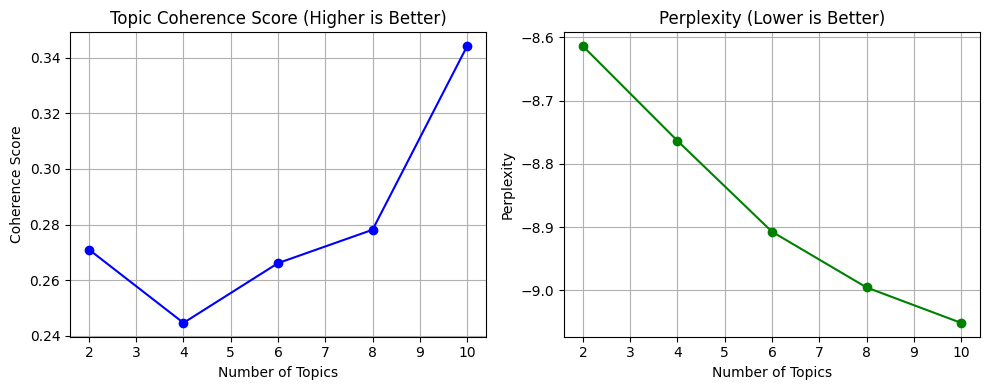

In [ ]:
# -------------------------------------------------------------
# 📦 Import libraries
# -------------------------------------------------------------
import matplotlib.pyplot as plt
from gensim import corpora, models
from gensim.models import CoherenceModel

# -------------------------------------------------------------
# 📊 Use your preprocessed data (replace below with your variables)
# -------------------------------------------------------------
# Example placeholders — replace with your own
texts = processed_docs          # Your tokenized, cleaned text data
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# -------------------------------------------------------------
# 🔁 Train multiple LDA models for different topic counts
# -------------------------------------------------------------
num_topics_list = [2, 4, 6, 8, 10]
coherence_scores = []
perplexity_scores = []

for num_topics in num_topics_list:
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )

    # Perplexity (lower is better)
    perplexity = lda_model.log_perplexity(corpus)
    perplexity_scores.append(perplexity)

    # Coherence (higher is better)
    coherence_model = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)

# -------------------------------------------------------------
# 📈 Plot Coherence & Perplexity
# -------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(num_topics_list, coherence_scores, marker='o', color='blue')
ax[0].set_title("Topic Coherence Score (Higher is Better)")
ax[0].set_xlabel("Number of Topics")
ax[0].set_ylabel("Coherence Score")
ax[0].grid(True)

ax[1].plot(num_topics_list, perplexity_scores, marker='o', color='green')
ax[1].set_title("Perplexity (Lower is Better)")
ax[1].set_xlabel("Number of Topics")
ax[1].set_ylabel("Perplexity")
ax[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------
# Step 1️⃣ - Import Libraries
# ---------------------------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Step 2️⃣ - Load and Prepare Data
# ---------------------------------------------------
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',
                           names=column_names, encoding='ISO-8859-1')

X = twitter_data['text']
Y = twitter_data['target']

# Optional: use a smaller sample if the dataset is large
X = X.sample(10000, random_state=42)
Y = Y.loc[X.index]

# ---------------------------------------------------
# Step 3️⃣ - Split Data
# ---------------------------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)



# ---------------------------------------------------
# Step 1️⃣1️⃣ - Classification Report
# ---------------------------------------------------
print("\n📋 Classification Report:\n")
print(classification_report(Y_test, Y_test_pred))



📋 Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       980
           4       0.72      0.70      0.71      1020

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000



✅ Dataset Loaded Successfully!
   target         ids                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


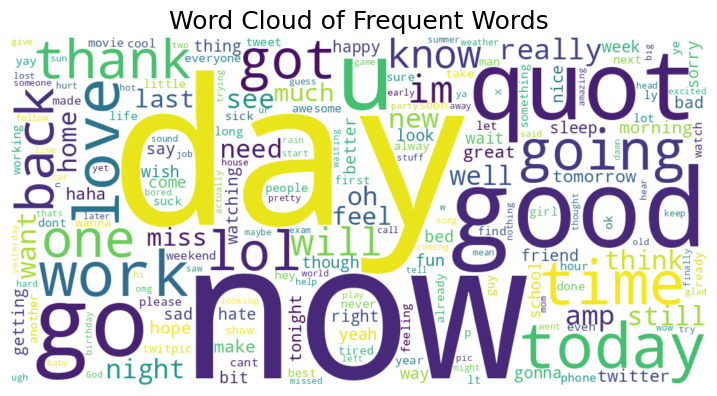

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Step 1️⃣ - Load Dataset with Correct Headers
# ---------------------------------------------------
df = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",
                 encoding='latin-1', header=None)

df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

print("✅ Dataset Loaded Successfully!")
print(df.head())

# ---------------------------------------------------
# Step 2️⃣ - Combine All Text for Word Cloud
# ---------------------------------------------------
all_words = ' '.join(df['text'].astype(str))

# ---------------------------------------------------
# Step 3️⃣ - Generate and Display Word Cloud
# ---------------------------------------------------
wordcloud = WordCloud(width=1000, height=500,
                      background_color='white',
                      collocations=False).generate(all_words)

plt.figure(figsize=(9,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Frequent Words', fontsize=18)
plt.show()


In [ ]:
import streamlit as st
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

st.title("🧠 Sentiment Analysis Dashboard")

uploaded_file = st.file_uploader("Upload your CSV dataset", type=['csv'])
if uploaded_file:
    df = pd.read_csv(uploaded_file, encoding='latin-1')
    st.write("Sample Data", df.head())

    # Select column
    text_column = st.selectbox("Select the text column:", df.columns)

    all_words = " ".join(df[text_column].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

    st.subheader("🌥 Word Cloud of Tweets")
    fig, ax = plt.subplots()
    ax.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    st.pyplot(fig)


2025-11-15 16:11:26.595 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:11:28.717 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-11-15 16:11:28.729 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:11:28.731 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:11:28.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:11:28.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:11:28.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-15 16:11:28.767 Thread 'MainThread': mi

In [ ]:
!pwd

/content


In [ ]:
!ls

drive	     sentiment140.zip	training.1600000.processed.noemoticon.csv
sample_data  trained_model.sav	vectorizer.sav


Overwriting app.py


In [ ]:
!killall ngrok

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

st.markdown(
    """
    <style>
    .title-text {
        font-size: 50px;
        font-weight: 900;
        background: linear-gradient(90deg, #ff0080, #ff9900, #00c6ff, #7b2ff7);
        -webkit-background-clip: text;
        color: transparent;
        text-align: center;
        margin-bottom: -10px;
    }
    .subtitle-text {
        font-size: 20px;
        font-style: italic;
        color: #444;
        text-align: center;
    }

    </style>

    <h1 class="title-text">Narrative Nexus</h1>
    <h4>Text Analysis Platform</h4>

    <p class="subtitle-text">“One comment… and the whole story shifts — perspectives change, emotions reroute, and a new narrative begins.”</p>
    <div class="sub-points">
    • Every word carries weight.<br>
    • Every shift creates meaning.<br>
    • Every meaning creates a new story.
    </div>
    """,
    unsafe_allow_html=True,
)



# -----------------------------------------
# Load Model & Vectorizer
# -----------------------------------------
model = pickle.load(open("trained_model.sav", "rb"))
vectorizer = pickle.load(open("vectorizer.sav", "rb"))

# -----------------------------------------
# Streamlit Config
# -----------------------------------------
st.set_page_config(page_title="Narrative Nexus", layout="wide")

# -----------------------------------------
# Navigation Menu (Animated Tabs)
# -----------------------------------------
pages = ["🏠 Home", "📤 Upload", "✍️ Sentiment Analysis", "📊 Report"]
page = st.sidebar.radio("Navigate", pages)

# -----------------------------------------
# App Title Area
# -----------------------------------------
st.title("🧠 Sentiment Analysis")
st.markdown("", unsafe_allow_html=True)


# -----------------------------------------
# Helper: Animated Sentiment Meter
# -----------------------------------------
def sentiment_meter(pred):
    if pred == 4:
        emoji, label, color, val = "😊", "Positive", "green", 100
    elif pred == 2:
        emoji, label, color, val = "😐", "Neutral", "orange", 50
    else:
        emoji, label, color, val = "😔", "Negative", "red", 0

    st.markdown(
        f"""
        <div style="padding:18px;border-radius:12px;background:{color};
        color:white;font-size:24px;text-align:center;">
        <b>{emoji} {label}</b>
        </div>
        """,
        unsafe_allow_html=True,
    )

    st.write("### Sentiment Meter")
    bar = st.progress(0)
    for i in range(val + 1):
        bar.progress(i)


# ============================================================
# 🏠 HOME PAGE
# ============================================================
if page == "🏠 Home":
    st.header("📊 Platform Dashboard Overview")
    st.write("A quick summary of analyzed sentiments.")

    # Example default values
    positive, neutral, negative = 45, 20, 35
    total = positive + neutral + negative

    col1, col2, col3 = st.columns(3)
    col1.metric("😊 Positive", positive)
    col2.metric("😐 Neutral", neutral)
    col3.metric("😔 Negative", negative)

    # Pie Chart
    st.write("### Sentiment Distribution Overview")
    labels = ["Positive", "Neutral", "Negative"]
    values = [positive, neutral, negative]

    fig, ax = plt.subplots()
    ax.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
    ax.axis("equal")
    st.pyplot(fig)


# ============================================================
# 📤 UPLOAD PAGE
# ============================================================
elif page == "📤 Upload":

    st.header("📤 Upload CSV for Batch Sentiment Analysis")

    uploaded_file = st.file_uploader("Upload CSV", type=["csv"])

    if uploaded_file:
        df = pd.read_csv(uploaded_file, encoding="latin-1")
        st.write("### Preview of Dataset")
        st.dataframe(df.head())

        text_col = st.selectbox("Choose text column:", df.columns)

        if st.button("Analyze File"):
            data = df[text_col].astype(str)
            X = vectorizer.transform(data)
            df["Predicted Sentiment"] = model.predict(X)

            st.success("Sentiment Analysis Completed!")
            st.dataframe(df.head(10))

            # Word Clouds
            st.write("### Word Cloud Summary")
            col1, col2 = st.columns(2)

            pos_words = " ".join(df[df["Predicted Sentiment"] == 4][text_col])
            neg_words = " ".join(df[df["Predicted Sentiment"] == 0][text_col])

            with col1:
                st.subheader("😊 Positive Word Cloud")
                if pos_words:
                    wc = WordCloud(width=400, height=300, background_color="white").generate(pos_words)
                    st.pyplot(plt.imshow(wc), clear_figure=True)

            with col2:
                st.subheader("😔 Negative Word Cloud")
                if neg_words:
                    wc = WordCloud(width=400, height=300, background_color="white").generate(neg_words)
                    st.pyplot(plt.imshow(wc), clear_figure=True)


# ============================================================
# ✍️ SINGLE SENTENCE ANALYSIS PAGE
# ============================================================
elif page == "✍️ Sentiment Analysis":

    st.header("✍️ Analyze a Sentence")

    user_input = st.text_area("Enter a sentence:", "")

    if st.button("Analyze Sentiment"):
        if user_input.strip() != "":
            vectorized = vectorizer.transform([user_input])
            prediction = model.predict(vectorized)[0]

            # Animated Meter
            sentiment_meter(prediction)

            # Probability Graph
            if hasattr(model, "predict_proba"):
                st.write("### Probability Distribution")
                proba = model.predict_proba(vectorized)[0]
                labels = ["Negative", "Neutral", "Positive"]

                fig, ax = plt.subplots()
                ax.bar(labels, proba)
                st.pyplot(fig)

        else:
            st.warning("Please type something before analyzing.")


# ============================================================
# 📊 REPORT PAGE
# ============================================================
elif page == "📊 Report":
    st.header("📊 Sentiment Report Summary")
    st.write("This section will show advanced analytics (full report).")

    st.info("📌 Report module will be expanded with advanced analytics, charts, and summaries.")




Overwriting app.py


In [ ]:
!pip install streamlit pyngrok -q

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("34kj2qYKO4eHKQLT98LBLJjV2dn_71yzRUz16XtvAYtW5irsC")


In [ ]:
%%writefile app.py
import streamlit as st

st.title("Sentiment Analyzer 😊😡")
text = st.text_area("Enter text to analyze:")

if st.button("Analyze"):
    st.write("✅ This is where your model prediction will appear!")

Overwriting app.py


In [ ]:
!pip install pyngrok
from pyngrok import ngrok

# Paste your authtoken (copied from https://dashboard.ngrok.com/get-started/your-authtoken)
ngrok.set_auth_token("34kj2qYKO4eHKQLT98LBLJjV2dn_71yzRUz16XtvAYtW5irsC")


In [ ]:
from pyngrok import ngrok

# connect port 6006 (your Streamlit app)
public_url = ngrok.connect(6006)
print("✅ Streamlit app is live at:", public_url)

✅ Streamlit app is live at: NgrokTunnel: "https://superadmirable-sheree-nonhunting.ngrok-free.dev" -> "http://localhost:6006"
